зафиксируем Seed, выберем устройство, на котором будет выполняться обучение

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
SEED = 42


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)
print("torchvision:", torchvision.__version__)

BATCH_SIZE = 512 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2

device: cuda
torch: 2.7.1+cu118
torchvision: 0.22.1+cu118


Выгрузим датасет EMNIST 

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_full = torchvision.datasets.EMNIST(
    root = "./data", train=True, download=True, transform=transform, split="balanced"
)

test_ds = torchvision.datasets.EMNIST(
    root = "./data", train=False, download=True, transform=transform, split="balanced"
)

class_names = train_full.classes

print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


In [3]:
val_ratio = 0.25
val_size = int(len(train_full)*val_ratio)
train_size = len(train_full)-val_size

gen = torch.Generator().manual_seed(SEED)

train_ds, val_ds = random_split(
    train_full, [train_size, val_size], generator=gen
)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda")
)

x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)
print("batch_size: ", x_batch.shape[0])
print(f"min x_batch unit: {x_batch.min().item():.4f},\n max x_batch unit: {x_batch.max().item():.4f}")
print(f"min y_batch unit: {y_batch.min().item():.4f},\n max y_batch unit: {y_batch.max().item():.4f}")

x_batch: torch.Size([512, 1, 28, 28]) torch.float32
y_batch: torch.Size([512]) torch.int64
batch_size:  512
min x_batch unit: -1.0000,
 max x_batch unit: 1.0000
min y_batch unit: 0.0000,
 max y_batch unit: 46.0000


Реализация MLP, обучения одной эпохи, постройки графика, Earlystopping,метода fit()

In [4]:
class MLP (nn.Module):
    def __init__(
            self,
            input_dim: int = 28*28,
            hidden_dims: tuple = (256, 128),
            num_clusses: int = 47,
            activation: str = "relu",
            dropout_p: float = 0.0,
            use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = torch.nn.ReLU
        else:
            raise ValueError(f"Unknown activation: {activation}")
        
        layers = [nn.Flatten()]

        prev = input_dim

        for h in hidden_dims:
            layers.append(torch.nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(torch.nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(torch.nn.Dropout(p=dropout_p))
            prev = h
        
        layers.append(torch.nn.Linear(prev, num_clusses))
        self.net = torch.nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)
    
model = MLP().to(device)

In [5]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0
    
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1
    
    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [6]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


In [7]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [8]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

### 3.1. Часть A (S08): регуляризация и переобучение 

In [9]:
criterion = torch.nn.CrossEntropyLoss()

modelE1 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)
optimizerE1 = optim.Adam(modelE1.parameters(), lr=1e-3)
modelE2 = MLP(hidden_dims=(256, 128), dropout_p=0.35, use_batchnorm=False).to(device)
optimizerE2 = optim.Adam(modelE2.parameters(), lr=1e-3)
modelE3 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
optimizerE3 = optim.Adam(modelE3.parameters(), lr=1e-3)

historyE1 = fit(
    modelE1, train_loader, val_loader,
    optimizerE1, criterion, device,
    epochs=20,
    early_stopping=None
)

historyE2 = fit(
    modelE2, train_loader, val_loader,
    optimizerE2, criterion, device,
    epochs=20,
    early_stopping=None,
    verbose=False,
)

historyE3 = fit(
    modelE3, train_loader, val_loader,
    optimizerE3, criterion, device,
    epochs=20,
    early_stopping=None,
    verbose=False,
)



test_loss, test_acc = evaluate(modelE1, test_loader, criterion, device)
print(f"modelE1: loss={test_loss:.4f}, acc={test_acc:.4f}")

test_loss, test_acc = evaluate(modelE2, test_loader, criterion, device)
print(f"modelE2: loss={test_loss:.4f}, acc={test_acc:.4f}")

test_loss, test_acc = evaluate(modelE3, test_loader, criterion, device)
print(f"modelE3: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/20 | train loss=1.7293, acc=0.5288 | val loss=1.1841, acc=0.6577
epoch 02/20 | train loss=1.0383, acc=0.6957 | val loss=0.9328, acc=0.7267
epoch 03/20 | train loss=0.8251, acc=0.7501 | val loss=0.7945, acc=0.7565
epoch 04/20 | train loss=0.6991, acc=0.7849 | val loss=0.6932, acc=0.7883
epoch 05/20 | train loss=0.6277, acc=0.8017 | val loss=0.6416, acc=0.7981
epoch 06/20 | train loss=0.5738, acc=0.8162 | val loss=0.6068, acc=0.8076
epoch 07/20 | train loss=0.5318, acc=0.8272 | val loss=0.5744, acc=0.8178
epoch 08/20 | train loss=0.5010, acc=0.8345 | val loss=0.5713, acc=0.8173
epoch 09/20 | train loss=0.4764, acc=0.8422 | val loss=0.5480, acc=0.8208
epoch 10/20 | train loss=0.4537, acc=0.8480 | val loss=0.5525, acc=0.8195
epoch 11/20 | train loss=0.4359, acc=0.8517 | val loss=0.5322, acc=0.8268
epoch 12/20 | train loss=0.4211, acc=0.8559 | val loss=0.5147, acc=0.8285
epoch 13/20 | train loss=0.4079, acc=0.8592 | val loss=0.5256, acc=0.8264
epoch 14/20 | train loss=0.3929, acc=0

Лучше всего себя показала модель modelE3, если оценивать по метрике точности

In [10]:
es = EarlyStopping(min_delta=0.0005)

modelE4 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
optimizerE4 = optim.Adam(modelE4.parameters(), lr=1e-3)

historyE4 = fit(
    modelE4, train_loader, val_loader,
    optimizerE4, criterion, device,
    epochs=20,
    early_stopping=es,
    verbose=True,
)

test_loss, test_acc = evaluate(modelE4, test_loader, criterion, device)
print(f"modelE4 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

tmp_path = 'artifacts\\best_model.pt'
torch.save(modelE4.state_dict(), tmp_path)

epoch 01/20 | train loss=1.4387, acc=0.6686 | val loss=0.8628, acc=0.7533
epoch 02/20 | train loss=0.6328, acc=0.8094 | val loss=0.5968, acc=0.8144
epoch 03/20 | train loss=0.4981, acc=0.8394 | val loss=0.5586, acc=0.8197
epoch 04/20 | train loss=0.4317, acc=0.8551 | val loss=0.5216, acc=0.8239
epoch 05/20 | train loss=0.3886, acc=0.8674 | val loss=0.4945, acc=0.8344
epoch 06/20 | train loss=0.3544, acc=0.8773 | val loss=0.4895, acc=0.8360
epoch 07/20 | train loss=0.3284, acc=0.8844 | val loss=0.4801, acc=0.8379
epoch 08/20 | train loss=0.3071, acc=0.8908 | val loss=0.4928, acc=0.8386
epoch 09/20 | train loss=0.2870, acc=0.8965 | val loss=0.4856, acc=0.8386
epoch 10/20 | train loss=0.2706, acc=0.9013 | val loss=0.4857, acc=0.8411
epoch 11/20 | train loss=0.2573, acc=0.9042 | val loss=0.4891, acc=0.8370
epoch 12/20 | train loss=0.2438, acc=0.9100 | val loss=0.5020, acc=0.8384
epoch 13/20 | train loss=0.2308, acc=0.9139 | val loss=0.5069, acc=0.8352
epoch 14/20 | train loss=0.2202, acc=0

epoch 01/5 | train loss=1.0603, acc=0.6829 | val loss=0.8344, acc=0.7350
epoch 02/5 | train loss=0.6599, acc=0.7851 | val loss=0.7336, acc=0.7646
epoch 03/5 | train loss=0.5787, acc=0.8055 | val loss=0.6560, acc=0.7856
epoch 04/5 | train loss=0.5311, acc=0.8183 | val loss=0.6562, acc=0.7979
epoch 05/5 | train loss=0.5024, acc=0.8263 | val loss=0.6225, acc=0.7983


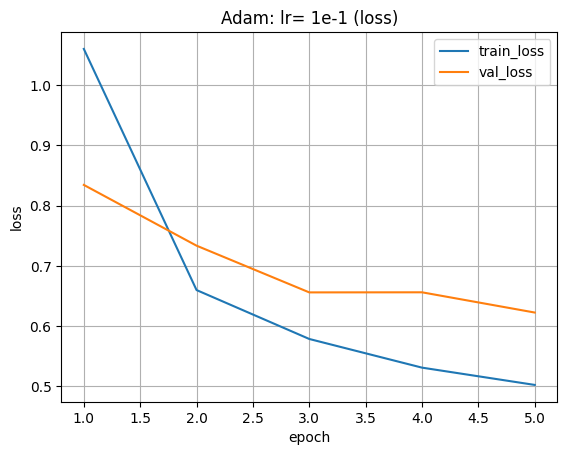

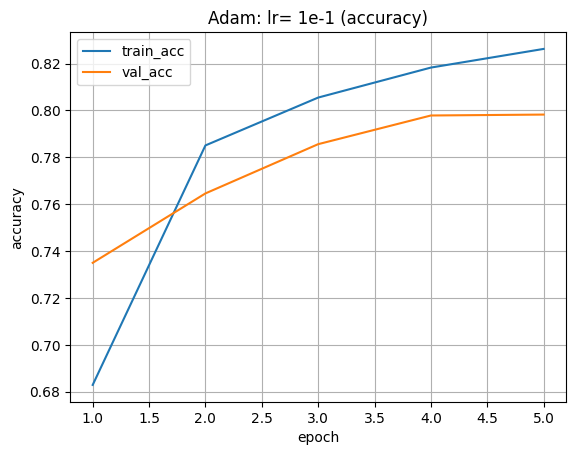

In [11]:
modelB1 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
optimizerB1 = optim.Adam(modelB1.parameters(), lr=1e-1)

historyB1 = fit(
    modelB1, train_loader, val_loader,
    optimizerB1, criterion, device,
    epochs=5,
    early_stopping=None
)

plot_history(historyB1, "Adam: lr= 1e-1")

С большим lr модель почти сразу приходит к эффекту "переобучения"

epoch 01/5 | train loss=3.7128, acc=0.0821 | val loss=3.5380, acc=0.1495
epoch 02/5 | train loss=3.4001, acc=0.2150 | val loss=3.2715, acc=0.2804
epoch 03/5 | train loss=3.1703, acc=0.3280 | val loss=3.0725, acc=0.3691
epoch 04/5 | train loss=2.9910, acc=0.4032 | val loss=2.9084, acc=0.4273
epoch 05/5 | train loss=2.8441, acc=0.4520 | val loss=2.7746, acc=0.4710


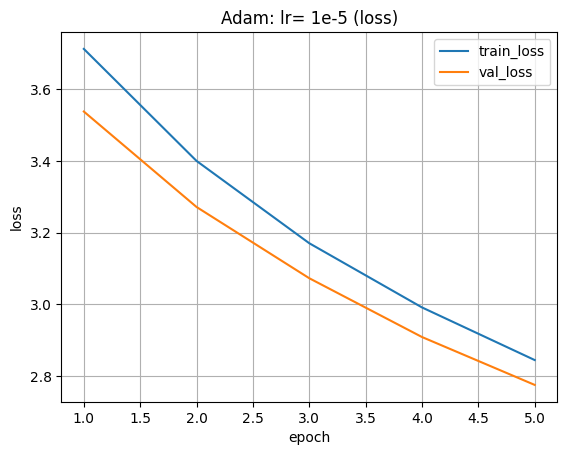

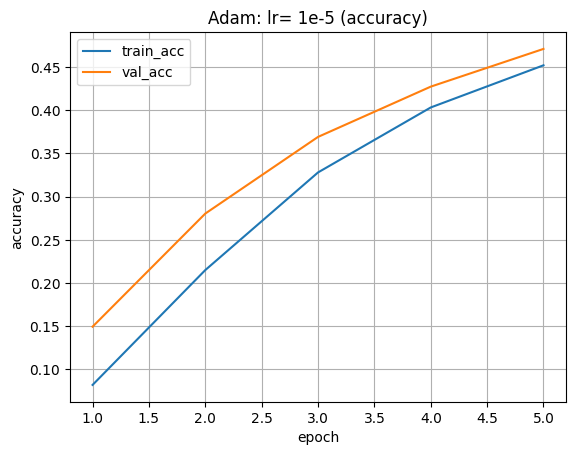

In [12]:
modelB2 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
optimizerB2 = optim.Adam(modelB2.parameters(), lr=1e-5)

historyB2 = fit(
    modelB2, train_loader, val_loader,
    optimizerB2, criterion, device,
    epochs=5,
    early_stopping=None
)

plot_history(historyB2, "Adam: lr= 1e-5")

Обучение почти не двигается

epoch 01/15 | train loss=3.3176, acc=0.2490 | val loss=2.8442, acc=0.4407
epoch 02/15 | train loss=2.5780, acc=0.5017 | val loss=2.3241, acc=0.5410
epoch 03/15 | train loss=2.1363, acc=0.5707 | val loss=1.9513, acc=0.5962
epoch 04/15 | train loss=1.8171, acc=0.6164 | val loss=1.6905, acc=0.6329
epoch 05/15 | train loss=1.5862, acc=0.6501 | val loss=1.5001, acc=0.6601
epoch 06/15 | train loss=1.4130, acc=0.6760 | val loss=1.3512, acc=0.6839
epoch 07/15 | train loss=1.2793, acc=0.6976 | val loss=1.2390, acc=0.7008
epoch 08/15 | train loss=1.1732, acc=0.7155 | val loss=1.1425, acc=0.7172
epoch 09/15 | train loss=1.0882, acc=0.7283 | val loss=1.0617, acc=0.7295
epoch 10/15 | train loss=1.0146, acc=0.7409 | val loss=1.0091, acc=0.7394
epoch 11/15 | train loss=0.9554, acc=0.7519 | val loss=0.9506, acc=0.7513
epoch 12/15 | train loss=0.9032, acc=0.7617 | val loss=0.9093, acc=0.7573
epoch 13/15 | train loss=0.8577, acc=0.7705 | val loss=0.8669, acc=0.7667
epoch 14/15 | train loss=0.8185, acc=0

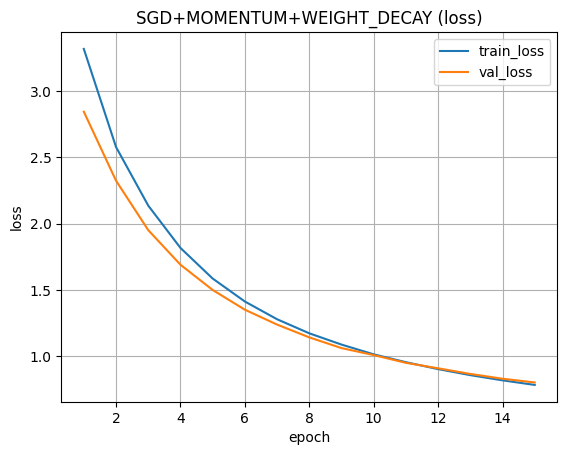

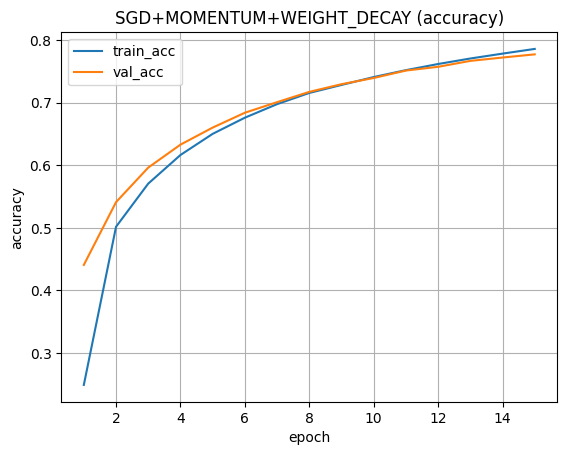

In [ ]:
modelB3 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
optimizerB3 = optim.SGD(modelB3.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)

historyB3 = fit(
    modelB3, train_loader, val_loader,
    optimizerB3, criterion, device,
    epochs=15,
    early_stopping=None
)
plot_history(historyB3, "SGD test")

In [14]:
# === Export experiment artifacts and visualizations ===

import os
import json
import pandas as pd
import matplotlib.pyplot as plt

DATASET_NAME = "EMNIST"
RANDOM_SEED = SEED


# ---- extract model architecture description ----
def get_model_description(net):

    hidden_layers = []
    activation_name = None
    dropout_value = 0.0
    has_bn = False

    for layer in net.net:

        if isinstance(layer, torch.nn.Linear):
            hidden_layers.append(layer.out_features)

        elif isinstance(layer, torch.nn.Dropout):
            dropout_value = layer.p

        elif isinstance(layer, torch.nn.BatchNorm1d):
            has_bn = True

        elif isinstance(layer, torch.nn.ReLU):
            activation_name = "relu"

    if len(hidden_layers) > 0:
        hidden_layers = hidden_layers[:-1]

    hidden_repr = "-".join(map(str, hidden_layers))

    return f"layers={hidden_repr} activation={activation_name} dropout={dropout_value} batchnorm={has_bn}"


# ---- find best validation epoch ----
def extract_best_result(log):

    best_epoch = min(range(len(log["val_loss"])), key=lambda i: log["val_loss"][i])

    return {
        "best_val_accuracy": log["val_acc"][best_epoch],
        "best_val_loss": log["val_loss"][best_epoch],
        "epochs_trained": best_epoch + 1
    }


# ---- experiment registry ----
experiments = [
    ("E1", modelE1, optimizerE1, historyE1),
    ("E2", modelE2, optimizerE2, historyE2),
    ("E3", modelE3, optimizerE3, historyE3),
    ("E4", modelE4, optimizerE4, historyE4),
    ("O1", modelB1, optimizerB1, historyB1),
    ("O2", modelB2, optimizerB2, historyB2),
    ("O3", modelB3, optimizerB3, historyB3),
]


results = []

for name, model, opt, history in experiments:

    opt_group = opt.param_groups[0]

    record = {
        "experiment_id": name,
        "dataset": DATASET_NAME,
        "seed": RANDOM_SEED,
        "model_summary": get_model_description(model),
        "optimizer": type(opt).__name__,
        "lr": opt_group["lr"],
        "momentum": opt_group.get("momentum", 0),
        "weight_decay": opt_group.get("weight_decay", 0)
    }

    record.update(extract_best_result(history))

    results.append(record)


# ---- save run table ----
runs_table = pd.DataFrame(results)

os.makedirs("artifacts", exist_ok=True)

runs_table.to_csv("artifacts/runs.csv", index=False)

print("runs.csv saved")
print(runs_table)


# ---- best configuration (based on experiment E4) ----
best_stats = extract_best_result(historyE4)

best_config = {
    "experiment_id": "E4",
    "dataset": DATASET_NAME,
    "seed": RANDOM_SEED,
    "model": {
        "hidden_dims": [256, 128],
        "dropout": 0.0,
        "use_batchnorm": True,
        "activation": "relu",
        "input_dim": 28 * 28,
        "num_classes": 47
    },
    "optimizer": {
        "type": "Adam",
        "lr": 1e-3,
        "momentum": 0,
        "weight_decay": 0
    },
    "epochs_trained": best_stats["epochs_trained"],
    "best_val_accuracy": best_stats["best_val_accuracy"],
    "best_val_loss": best_stats["best_val_loss"]
}

with open("artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=2)

print("best_config.json saved")


# ---- plot best experiment curves ----
def plot_training_curves(history, title, save_path):

    epochs = list(range(1, len(history["train_loss"]) + 1))

    plt.figure(figsize=(6,4))

    plt.plot(epochs, history["train_loss"], label="train")
    plt.plot(epochs, history["val_loss"], label="validation")

    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title)

    plt.legend()
    plt.grid(True)

    plt.savefig(save_path)
    plt.close()


os.makedirs("artifacts/figures", exist_ok=True)

plot_training_curves(
    historyE4,
    "Best model training",
    "artifacts/figures/curves_best.png"
)

print("curves_best.png saved")


# ---- compare extreme learning rates ----
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plot_history = historyB1
epochs = range(1, len(plot_history["train_loss"]) + 1)
plt.plot(epochs, plot_history["train_loss"], label="train")
plt.plot(epochs, plot_history["val_loss"], label="val")
plt.title("High learning rate")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plot_history = historyB2
epochs = range(1, len(plot_history["train_loss"]) + 1)
plt.plot(epochs, plot_history["train_loss"], label="train")
plt.plot(epochs, plot_history["val_loss"], label="val")
plt.title("Low learning rate")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)

plt.savefig("artifacts/figures/curves_lr_extremes.png")
plt.close()

print("curves_lr_extremes.png saved")

runs.csv saved
  experiment_id dataset  seed  \
0            E1  EMNIST    42   
1            E2  EMNIST    42   
2            E3  EMNIST    42   
3            E4  EMNIST    42   
4            O1  EMNIST    42   
5            O2  EMNIST    42   
6            O3  EMNIST    42   

                                       model_summary optimizer       lr  \
0  layers=256-128 activation=relu dropout=0.0 bat...      Adam  0.00100   
1  layers=256-128 activation=relu dropout=0.35 ba...      Adam  0.00100   
2  layers=256-128 activation=relu dropout=0.0 bat...      Adam  0.00100   
3  layers=256-128 activation=relu dropout=0.0 bat...      Adam  0.00100   
4  layers=256-128 activation=relu dropout=0.0 bat...      Adam  0.10000   
5  layers=256-128 activation=relu dropout=0.0 bat...      Adam  0.00001   
6  layers=256-128 activation=relu dropout=0.0 bat...       SGD  0.00100   

   momentum  weight_decay  best_val_accuracy  best_val_loss  epochs_trained  
0       0.0        0.0000           0.839